# FEM - Plane Strain

# Virtual work expressions (PVW)

$$
\int_{\Omega} \left[\delta \boldsymbol{\varepsilon}\right]^T \boldsymbol{\sigma}\, d\Omega
-\int_{\Omega} \left[\delta \boldsymbol{u}\right]^T \boldsymbol{b}\, d\Omega
-\int_{\Gamma_t} \left[\delta \boldsymbol{u}\right]^T \boldsymbol{t}\, d\Gamma
= 0
$$

$
\begin{aligned}
\boldsymbol{\sigma} &: \text{ vector of stresses} \\
\boldsymbol{t} &: \text{ vector of boundary tractions} \\
\delta \boldsymbol{u} &: \text{ vector of virtual displacements} \\
\delta \boldsymbol{\varepsilon} &: \text{ vector of associated virtual strains} \\
\Omega &: \text{ domain of interest} \\
\Gamma_t &: \text{ part of the boundary where tractions are prescribed} \\
\Gamma_u &: \text{ part of the boundary where displacements are prescribed}
\end{aligned}
$


## 1. Propriedades do material

Definimos:

- $E$ : módulo de elasticidade  
- $\nu$ : coeficiente de Poisson  
- $h$ : espessura da placa  
- $\rho$ : densidade do material
- $I = \frac{h^3}{12}$ : momento de inércia da seção (controla rigidez à flexão da placa).
- $\kappa$ = 0.8601 --> fator de correção de cisalhamento, depende da formulação e das condições de contorno ('CCCC')


---

## 2. Matriz constitutiva de flexão

A matriz constitutiva de flexão (relaciona curvaturas da placa e momentos fletores internos):

$$
D_b =
\frac{E I}{1-\nu^2}
\begin{bmatrix}
1 & \nu & 0 \\
\nu & 1 & 0 \\
0 & 0 & \frac{1-\nu}{2}
\end{bmatrix}
$$

---

## 3. Matriz constitutiva de cisalhamento

A matriz constitutiva do cisalhamento transversal relaciona deformações de cisalhamento esforços cortantes internos
 
$$
D_s =
\frac{E \kappa h}{2(1+\nu)}
\mathbf{I}
$$

---

##  Aplicação no MEF

Essas matrizes serão usadas posteriormente na montagem da rigidez do elemento:

$$
K =
\int_{\Omega}
B^T D B \, d\Omega
$$

onde:

- $B$ = matriz deformação-deslocamento  
- $D$ = matriz constitutiva  
- $K$ = matriz de rigidez do elemento  

In [1]:
import numpy as np

# =========================
# Material properties
# =========================
E = 10920.0
poisson = 0.30

thickness = 0.1
I = thickness**3 / 12.0

rho = 1.0

# Shear correction factor
# cccc / cccf
kappa = 0.8601

# Alternative cases:
# kappa = 0.822     # scsc
# kappa = 5.0/6.0  # ssss


# =========================
# Constitutive matrices
# =========================

# Bending constitutive matrix
D_bending = (
    I * E / (1.0 - poisson**2)
) * np.array([
    [1.0, poisson, 0.0],
    [poisson, 1.0, 0.0],
    [0.0, 0.0, (1.0 - poisson)/2.0]
])

# Shear constitutive matrix
D_shear = (
    kappa * thickness * E / (2.0 * (1.0 + poisson))
) * np.eye(2)


print("D_bending =")
print(D_bending)

print("\nD_shear =")
print(D_shear)

D_bending =
[[1.   0.3  0.  ]
 [0.3  1.   0.  ]
 [0.   0.   0.35]]

D_shear =
[[361.242   0.   ]
 [  0.    361.242]]


# Discretização da malha de elementos finitos

Nesta etapa o domínio da placa é discretizado em elementos finitos quadriláteros de 4 nós (Q4).

## 4. Domínio físico e discretização espacial

$$
L = 1
$$

Logo, o domínio analisado é:

$$
\Omega = [0,L]\times[0,L]
$$

O domínio é dividido em:

- $n_x = 10$ elementos na direção $x$
- $n_y = 10$ elementos na direção $y$

Total de elementos:

$$
n_{el} = n_x n_y
$$

Neste caso:

$$
n_{el} = 10 \times 10 = 100
$$



In [2]:
# ==================================
# Meshing
# ==================================
L = 1.0

number_elements_x = 10
number_elements_y = 10

number_elements = number_elements_x * number_elements_y
number_nodes = (number_elements_x+1) * (number_elements_y+1)


print("Number of elements =", number_elements)
print("Number of nodes =", number_nodes)

Number of elements = 100
Number of nodes = 121


---

## 5. Geração da malha

A rotina `rectangularMesh()` gera:

### 5.1 Coordenadas nodais

$$
\mathbf{x}_i =
\begin{bmatrix}
x_i \\
y_i
\end{bmatrix}
\quad,\quad i=1,\dots,n_{nodes}
$$

onde cada nó possui suas coordenadas no domínio físico, com:

$$
x_i = i\Delta x
$$

$$
y_j = j\Delta y
$$

onde:

$$
i=0,\dots,n_x
$$

$$
j=0,\dots,n_y
$$

O número total de nós é:

$$
n_{nodes}=(n_x+1)(n_y+1)
$$

Neste problema:

$$
n_{nodes}=121
$$

---

### 5.2 Conectividade dos elementos

Cada elemento quadrilateral Q4 possui 4 nós:

$$
e =
[n_1,n_2,n_3,n_4]
$$

Essa conectividade define como os nós formam cada elemento finito.

O tamanho de cada elemento é calculado por:

$$
\Delta x=\frac{L_x}{n_x}
$$

$$
\Delta y=\frac{L_y}{n_y}
$$

Como a malha é uniforme, todos os elementos possuem as mesmas dimensões. Seguindo a convenção:

$$
[1,2,3,4]
=
[\text{inferior esquerdo},
\text{inferior direito},
\text{superior direito},
\text{superior esquerdo}]
$$

A conectividade local de cada elemento define como os elementos são montados globalmente.

---

Para o número total de graus de liberdade ($\theta_x, \theta_y, w$):
$$
GDof = 3 \times n_{nodes} = 3 \times 121 = 363
$$


In [3]:
import numpy as np
import matplotlib.pyplot as plt


def rectangular_mesh(Lx, Ly, number_elements_x, number_elements_y):
    """
    Generates a structured rectangular Q4 mesh.

    Returns
    -------
    node_coordinates : ndarray
        [n_nodes x 2] → [x, y]

    element_nodes : ndarray
        [n_elements x 4]

    Node ordering (Q4):
        [1,2,3,4] =
        [bottom-left, bottom-right, top-right, top-left]
    """

    dx = Lx / number_elements_x
    dy = Ly / number_elements_y

    # Number of nodes
    number_nodes_x = number_elements_x + 1
    number_nodes_y = number_elements_y + 1

    # ==================================
    # Nodal coordinates
    # ==================================
    node_coordinates = []

    for j in range(number_nodes_y):

        y = j * dy

        for i in range(number_nodes_x):

            x = i * dx

            node_coordinates.append([x, y])

    node_coordinates = np.array(node_coordinates)

    # ==================================
    # Element connectivity
    # ==================================
    element_nodes = []

    for j in range(1, number_elements_y + 1):

        for i in range(1, number_elements_x + 1):

            # +1 removed because Python starts at zero
            n1 = (j - 1) * number_nodes_x + (i - 1)
            n2 = n1 + 1
            n4 = j * number_nodes_x + (i - 1)
            n3 = n4 + 1

            element_nodes.append([n1, n2, n3, n4])

    element_nodes = np.array(element_nodes)

    return node_coordinates, element_nodes

    ##
    # GDof: global number of degrees of freedom
GDof=3*number_nodes;
print("Global number of degrees of freedom =", GDof)


Global number of degrees of freedom = 363


---

## 6. Representação gráfica (Opcional)

A malha é plotada para verificar:

- geometria do domínio
- distribuição nodal
- conectividade dos elementos
- numeração dos nós

Essa verificação é importante antes da montagem das matrizes globais.

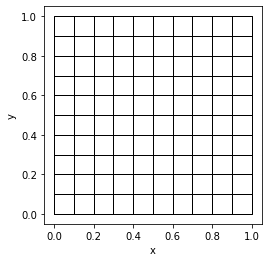

Number of elements = 100
Number of nodes = 121


In [4]:
def draw_mesh(node_coordinates, element_nodes, element_type='Q4'):
    """
    Draw finite element mesh.
    """

    fig, ax = plt.subplots()

    if element_type.upper() == 'Q4':
        order = [0, 1, 2, 3, 0]

    elif element_type.upper() == 'T3':
        order = [0, 1, 2, 0]

    else:
        raise ValueError("Unsupported element type.")

    number_elements = element_nodes.shape[0]

    for e in range(number_elements):

        nodes = element_nodes[e]

        x = node_coordinates[nodes[order], 0]
        y = node_coordinates[nodes[order], 1]

        ax.plot(x, y, 'k-', linewidth=1)

    ax.set_aspect('equal')
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    plt.show()




node_coordinates, element_nodes = rectangular_mesh(
    L, L,
    number_elements_x,
    number_elements_y
)

# Separate x and y coordinates
xx = node_coordinates[:, 0]
yy = node_coordinates[:, 1]

# Draw mesh
draw_mesh(node_coordinates, element_nodes, 'Q4')

# Total number of nodes
number_nodes = len(xx)

print("Number of elements =", number_elements)
print("Number of nodes =", number_nodes)

# 7. Funções de forma do elemento Q4

O elemento quadrilateral de 4 nós (Q4) é definido no sistema de coordenadas naturais:

$$
-1 \le \xi \le 1
$$

$$
-1 \le \eta \le 1
$$

Cada ponto interno do elemento é interpolado pelas funções de forma:

$$
u(\xi,\eta)=\sum_{i=1}^{4} N_i(\xi,\eta) u_i
$$

onde $N_i$ são as funções de forma nodais.

---

## 7.1. Funções de forma

Para o elemento Q4:

$$
N_i=
\frac{1}{4}(1+\xi\xi_i)(1+\eta\eta_i)
$$

---

## 7.2. Vetor de interpolação

As funções de forma são agrupadas em:

$$
N=
\begin{bmatrix}
N_1 & N_2 & N_3 & N_4
\end{bmatrix}
$$

---

## 7.3. Derivadas naturais

As derivadas das funções de forma são:

$$
\frac{\partial N_i}{\partial \xi}
\quad,\quad
\frac{\partial N_i}{\partial \eta}
$$

Essas derivadas são usadas para construir:

- matriz Jacobiana;
- derivadas em coordenadas físicas;
- matrizes $B$ do elemento.

In [5]:
def get_shape_function(xi, eta, element_type='Q4'):
    """
    Shape functions and natural derivatives.
    
    Parameters
    ----------
    xi, eta : float
        Natural coordinates

    element_type : str
        Element type ('Q4', 'T3', ...)

    Returns
    -------
    shape : ndarray
        Shape functions
    natural_derivatives : ndarray
        [dN/dxi, dN/deta]
    """
    element_type = element_type.upper()

    # ============= Q4===========================
    if element_type == 'Q4':
        # Shape functions
        shape = 0.25 * np.array([
            (1 - xi) * (1 - eta),
            (1 + xi) * (1 - eta),
            (1 + xi) * (1 + eta),
            (1 - xi) * (1 + eta)
        ])
        # Natural derivatives
        natural_derivatives = 0.25 * np.array([
            [-(1 - eta), -(1 - xi)],
            [ (1 - eta), -(1 + xi)],
            [ (1 + eta),  (1 + xi)],
            [-(1 + eta),  (1 - xi)]
        ])

    # =========== T3 ===========================
    elif element_type == 'T3':
        shape = np.array([
            1 - xi - eta,
            xi,
            eta
        ])

        natural_derivatives = np.array([
            [-1.0, -1.0],
            [ 1.0,  0.0],
            [ 0.0,  1.0]
        ])
    else:
        raise ValueError("Unsupported element type.")
    return shape, natural_derivatives

N, dN = get_shape_function(0.0, 0.0, 'Q4')

print("Shape functions in (0,0) :")
print(N)

print("\nNatural derivatives:")
print(dN)

Shape functions in (0,0) :
[0.25 0.25 0.25 0.25]

Natural derivatives:
[[-0.25 -0.25]
 [ 0.25 -0.25]
 [ 0.25  0.25]
 [-0.25  0.25]]


# 8. Transformação geométrica e matriz Jacobiana

As funções de forma são inicialmente derivadas no sistema natural:

$$
(\xi,\eta)
$$

Para montar a rigidez do elemento, precisamos obter derivadas no sistema físico:

$$
(x,y)
$$

Essa transformação é feita pela matriz Jacobiana.

---

## 8.1. Matriz Jacobiana

A matriz Jacobiana é definida por:

$$
J=
\frac{\partial(x,y)}{\partial(\xi,\eta)}
$$

ou explicitamente:

$$
J=
\begin{bmatrix}
\frac{\partial x}{\partial \xi} &
\frac{\partial x}{\partial \eta}
\\
\frac{\partial y}{\partial \xi} &
\frac{\partial y}{\partial \eta}
\end{bmatrix}
$$

No código, ela é calculada por:

$$
J = X^T \frac{\partial N}{\partial (\xi,\eta)}
$$

onde:

- $X$ = coordenadas nodais do elemento;
- $N$ = funções de forma.

---

## 8.2. Inversa do Jacobiano

A transformação de coordenadas usa:

$$
J^{-1}
$$

---

## 8.3. Derivadas em coordenadas físicas

As derivadas espaciais são obtidas por:

$$
\frac{\partial N}{\partial(x,y)}
=
\frac{\partial N}{\partial(\xi,\eta)}
J^{-1}
$$

Essas derivadas são usadas para montar as matrizes:

$$
B_b
\quad,\quad
B_s
$$

do elemento de Mindlin.

In [6]:
def get_jacobian(node_coordinates, natural_derivatives):
    """
    Compute element Jacobian.

    Parameters
    ----------
    node_coordinates : ndarray
        Element nodal coordinates [n_nodes x 2]

    natural_derivatives : ndarray
        Shape function derivatives in natural coordinates
        [n_nodes x 2]

    Returns
    -------
    J : ndarray
        Jacobian matrix

    invJ : ndarray
        Inverse Jacobian

    derivatives : ndarray
        Shape function derivatives in physical coordinates
        [dN/dx, dN/dy]
    """

    # Jacobian matrix
    J = node_coordinates.T @ natural_derivatives

    # Inverse Jacobian
    invJ = np.linalg.inv(J)

    # Spatial derivatives
    derivatives = natural_derivatives @ invJ

    return J, invJ, derivatives

element = 0
indice = element_nodes[element]
coords = node_coordinates[indice]
N, dN_nat = get_shape_function(0.0, 0.0, 'Q4')
J, invJ, dN_xy = get_jacobian(coords, dN_nat)
print("Element nodes:")
print(indice)
print("\nJacobian:")
print(J)
print("\nDeterminante:")
print(np.linalg.det(J))
print("\nSpatial derivatives:")
print(dN_xy)

Element nodes:
[ 0  1 12 11]

Jacobian:
[[0.05 0.  ]
 [0.   0.05]]

Determinante:
0.0025000000000000005

Spatial derivatives:
[[-5. -5.]
 [ 5. -5.]
 [ 5.  5.]
 [-5.  5.]]


# 9. Integração numérica de Gauss

As integrais dos elementos finitos são calculadas numericamente usando quadratura de Gauss.

A integral no domínio natural do elemento é aproximada por:

$$
\int_{-1}^{1}\int_{-1}^{1}
f(\xi,\eta)
\, d\xi d\eta
\approx
\sum_{i=1}^{n_g}
w_i f(\xi_i,\eta_i)
$$

onde:

- $(\xi_i,\eta_i)$ são os pontos de integração;
- $w_i$ são os pesos de integração;
- $n_g$ é o número de pontos de Gauss.

---

## 9.1. Integração reduzida (1×1)

Usada na parte de cisalhamento para reduzir *shear locking*.

Ponto de integração:

$$
(\xi,\eta)=(0,0)
$$

Peso:

$$
w=4
$$

---

## 9.2. Integração completa (2×2)

Usada na parte de flexão.

Os pontos são:

$$
\xi,\eta=\pm \frac{1}{\sqrt{3}}
$$

ou aproximadamente:

$$
\xi,\eta=\pm0.577350269
$$

Total de pontos:

$$
n_g=4
$$

Cada ponto possui peso:

$$
w=1
$$

---

## 9.3. Integração refinada (3×3)

Pode ser usada quando se deseja maior precisão numérica.

Neste caso:

$$
\xi,\eta=
\{-0.774596669,\;0,\;+0.774596669\}
$$

Total de pontos:

$$
n_g=9
$$

In [7]:
def get_gauss_quadrature(order_type):
    """
    Gauss quadrature for quadrilateral elements.

    Options:
        'reduced'  -> 1x1
        'complete' -> 2x2
        '1x1'
        '2x2'
        '3x3'
    """
    order_type = order_type.lower()
    # ======== 1x1 quadrature =======================
    if order_type in ['1x1', 'reduced']:

        gauss_locations = np.array([
            [0.0, 0.0]
        ])

        gauss_weights = np.array([
            4.0
        ])

    # ======== 2x2 quadrature =======================
    elif order_type in ['2x2', 'complete']:
        a = 1.0 / np.sqrt(3.0)
        gauss_locations = np.array([
            [-a, -a],
            [ a, -a],
            [ a,  a],
            [-a,  a]
        ])
        gauss_weights = np.ones(4)
        
    # ======== 3x3 quadrature ========================
    elif order_type == '3x3':
        a = np.sqrt(3.0/5.0)
        gauss_locations = np.array([
            [-a, -a],
            [-a,  0.0],
            [-a,  a],

            [0.0, -a],
            [0.0,  0.0],
            [0.0,  a],

            [a, -a],
            [a,  0.0],
            [a,  a]
        ])

        w1 = 5.0/9.0
        w2 = 8.0/9.0

        gauss_weights = np.array([
            w1*w1,
            w1*w2,
            w1*w1,

            w2*w1,
            w2*w2,
            w2*w1,

            w1*w1,
            w1*w2,
            w1*w1
        ])
    else:
        raise ValueError("Unsupported quadrature type.")
    return gauss_weights, gauss_locations

# =====================================
# Test: Gauss integration on element 0
# =====================================
element = 0
# Connectivity of element 0
indice = element_nodes[element]
# Coordinates of element 0
coords = node_coordinates[indice]
print("Element 0 connectivity:")
print(indice)
print("\nElement 0 coordinates:")
print(coords)
# Get Gauss points (same used in bending)
weights, points = get_gauss_quadrature("complete")
print("\nGauss points:")
print(points)
print("\nGauss weights:")
print(weights)
# Loop over Gauss points
for q in range(len(weights)):
    xi = points[q, 0]
    eta = points[q, 1]
    # Shape functions
    N, dN_nat = get_shape_function(xi, eta, 'Q4')
    # Jacobian
    J, invJ, dN_xy = get_jacobian(coords, dN_nat)
    print(f"\n========================")
    print(f"Gauss point {q+1}")
    print(f"xi = {xi:.6f}, eta = {eta:.6f}")
    print("\nShape functions:")
    print(N)
    print("\nJacobian:")
    print(J)
    print("\nDet(J):")
    print(np.linalg.det(J))
    print("\nSpatial derivatives:")
    print(dN_xy)

Element 0 connectivity:
[ 0  1 12 11]

Element 0 coordinates:
[[0.  0. ]
 [0.1 0. ]
 [0.1 0.1]
 [0.  0.1]]

Gauss points:
[[-0.57735027 -0.57735027]
 [ 0.57735027 -0.57735027]
 [ 0.57735027  0.57735027]
 [-0.57735027  0.57735027]]

Gauss weights:
[1. 1. 1. 1.]

Gauss point 1
xi = -0.577350, eta = -0.577350

Shape functions:
[0.62200847 0.16666667 0.0446582  0.16666667]

Jacobian:
[[ 5.00000000e-02  2.39599633e-19]
 [-2.39599633e-19  5.00000000e-02]]

Det(J):
0.0024999999999999983

Spatial derivatives:
[[-7.88675135 -7.88675135]
 [ 7.88675135 -2.11324865]
 [ 2.11324865  2.11324865]
 [-2.11324865  7.88675135]]

Gauss point 2
xi = 0.577350, eta = -0.577350

Shape functions:
[0.16666667 0.62200847 0.16666667 0.0446582 ]

Jacobian:
[[ 5.00000000e-02  2.18901323e-18]
 [-2.39599633e-19  5.00000000e-02]]

Det(J):
0.0024999999999999983

Spatial derivatives:
[[-7.88675135 -2.11324865]
 [ 7.88675135 -7.88675135]
 [ 2.11324865  7.88675135]
 [-2.11324865  2.11324865]]

Gauss point 3
xi = 0.577350, 

In [8]:
# =====================================
# Test: Gauss integration on element 0
# =====================================
element = 1
# Connectivity of element 0
indice = element_nodes[element]
# Coordinates of element 0
coords = node_coordinates[indice]
print("Element 1 connectivity:")
print(indice)
print("\nElement 1 coordinates:")
print(coords)
# Get Gauss points (same used in bending)
weights, points = get_gauss_quadrature("complete")
print("\nGauss points:")
print(points)
print("\nGauss weights:")
print(weights)
# Loop over Gauss points
for q in range(len(weights)):
    xi = points[q, 0]
    eta = points[q, 1]
    # Shape functions
    N, dN_nat = get_shape_function(xi, eta, 'Q4')
    # Jacobian
    J, invJ, dN_xy = get_jacobian(coords, dN_nat)
    print(f"\n========================")
    print(f"Gauss point {q+1}")
    print(f"xi = {xi:.6f}, eta = {eta:.6f}")
    print("\nShape functions:")
    print(N)
    print("\nJacobian:")
    print(J)
    print("\nDet(J):")
    print(np.linalg.det(J))
    print("\nSpatial derivatives:")
    print(dN_xy)

Element 1 connectivity:
[ 1  2 13 12]

Element 1 coordinates:
[[0.1 0. ]
 [0.2 0. ]
 [0.2 0.1]
 [0.1 0.1]]

Gauss points:
[[-0.57735027 -0.57735027]
 [ 0.57735027 -0.57735027]
 [ 0.57735027  0.57735027]
 [-0.57735027  0.57735027]]

Gauss weights:
[1. 1. 1. 1.]

Gauss point 1
xi = -0.577350, eta = -0.577350

Shape functions:
[0.62200847 0.16666667 0.0446582  0.16666667]

Jacobian:
[[ 5.00000000e-02  2.18901323e-18]
 [-2.39599633e-19  5.00000000e-02]]

Det(J):
0.0025000000000000005

Spatial derivatives:
[[-7.88675135 -7.88675135]
 [ 7.88675135 -2.11324865]
 [ 2.11324865  2.11324865]
 [-2.11324865  7.88675135]]

Gauss point 2
xi = 0.577350, eta = -0.577350

Shape functions:
[0.16666667 0.62200847 0.16666667 0.0446582 ]

Jacobian:
[[ 5.00000000e-02  2.39599633e-19]
 [-2.39599633e-19  5.00000000e-02]]

Det(J):
0.0024999999999999983

Spatial derivatives:
[[-7.88675135 -2.11324865]
 [ 7.88675135 -7.88675135]
 [ 2.11324865  7.88675135]
 [-2.11324865  2.11324865]]

Gauss point 3
xi = 0.577350, 

# 10. Montagem da matriz global de rigidez

$$
K = K_b + K_s
$$

A rigidez total do elemento é composta por duas contribuições:

- $K_b$: flexão da placa;
- $K_s$: cisalhamento transversal.

---

## 10.1. Rigidez de flexão

A contribuição de flexão é obtida por:

$$
K_b^{(e)}=
\int_{\Omega_e}
B_b^T
D_b
B_b
\, d\Omega
$$

onde:

- $B_b$ = matriz deformação-curvatura;
- $D_b$ = matriz constitutiva de flexão;
- $\Omega_e$ = domínio do elemento.

*A integração numérica é feita com quadratura completa de Gauss.

---

## 10.2. Rigidez de cisalhamento

A contribuição de cisalhamento é:

$$
K_s^{(e)}=
\int_{\Omega_e}
B_s^T
D_s
B_s
\, d\Omega
$$

onde:

- $B_s$ = matriz de deformação de cisalhamento;
- $D_s$ = matriz constitutiva de cisalhamento.

**A integração numérica é feita com quadratura reduzida.

Isso reduz o efeito de *shear locking*.

---

## 10.3. Transformação geométrica

As derivadas naturais $(\xi,\eta)$ são transformadas para coordenadas físicas $(x,y)$ usando o Jacobiano:

$$
J=
\frac{\partial(x,y)}{\partial(\xi,\eta)}
$$

---

## 10.4. Montagem global

Cada matriz de elemento é adicionada na matriz global através do mapeamento dos graus de liberdade:

$$
K^{global}
\leftarrow
K^{global}+K^{(e)}
$$

Cada nó possui 3 graus de liberdade:

$$
[w,\theta_x,\theta_y]
$$

portanto um elemento Q4 possui:

$$
4 \times 3 = 12
$$

graus de liberdade.

In [20]:
import numpy as np
def form_stiffness_matrix_mindlin_q4(
    GDof,
    number_elements,
    element_nodes,
    number_nodes,
    node_coordinates,
    C_shear,
    C_bending
):
    """
    Global stiffness matrix for Mindlin Q4 plate.
    """
    # Global stiffness matrix
    K = np.zeros((GDof, GDof))
    # ==========================================
    # BENDING CONTRIBUTION
    # ==========================================
    
    gauss_weights, gauss_locations = get_gauss_quadrature("complete")
    
    for e in range(number_elements):
        # element connectivity
        indice = element_nodes[e]
        # global DOF mapping
        element_dof = np.concatenate([
            indice,
            indice + number_nodes,
            indice + 2*number_nodes
        ])
        ndof = len(indice)
        for q in range(len(gauss_weights)):
            xi = gauss_locations[q,0]
            eta = gauss_locations[q,1]
            # Shape functions
            shape, natural_derivatives = get_shape_function(
                xi, eta, "Q4"
            )
            # Jacobian
            Jacob, invJacobian, XYderivatives = get_jacobian(
                node_coordinates[indice,:],
                natural_derivatives
            )
            # -------------------------
            # B matrix: bending
            # -------------------------
            B_b = np.zeros((3, 3*ndof))
            B_b[0, ndof:2*ndof] = XYderivatives[:,0]
            B_b[1, 2*ndof:3*ndof] = XYderivatives[:,1]
            B_b[2, ndof:2*ndof] = XYderivatives[:,1]
            B_b[2, 2*ndof:3*ndof] = XYderivatives[:,0]
            # element stiffness
            Ke = (
                B_b.T
                @ C_bending
                @ B_b
                * gauss_weights[q]
                * np.linalg.det(Jacob)
            )
            # Assembly
            K[np.ix_(element_dof, element_dof)] += Ke
            
    # ==========================================
    # SHEAR CONTRIBUTION
    # ==========================================
    gauss_weights, gauss_locations = get_gauss_quadrature("reduced")

    for e in range(number_elements):
        indice = element_nodes[e]
        element_dof = np.concatenate([
            indice,
            indice + number_nodes,
            indice + 2*number_nodes
        ])
        ndof = len(indice)
        for q in range(len(gauss_weights)):
            xi = gauss_locations[q,0]
            eta = gauss_locations[q,1]
            shape, natural_derivatives = get_shape_function(
                xi, eta, "Q4"
            )
            Jacob, invJacobian, XYderivatives = get_jacobian(
                node_coordinates[indice,:],
                natural_derivatives
            )
            # -------------------------
            # B matrix: shear
            # -------------------------
            B_s = np.zeros((2, 3*ndof))

            B_s[0, 0:ndof] = XYderivatives[:,0]
            B_s[1, 0:ndof] = XYderivatives[:,1]

            B_s[0, ndof:2*ndof] = shape
            B_s[1, 2*ndof:3*ndof] = shape

            # element stiffness
            Ke = (
                B_s.T
                @ C_shear
                @ B_s
                * gauss_weights[q]
                * np.linalg.det(Jacob)
            )

            # Assembly
            K[np.ix_(element_dof, element_dof)] += Ke

    return K

In [21]:
# =====================================
# Test: Global stiffness matrix
# =====================================

# Total degrees of freedom
# Each node has:
# w, theta_x, theta_y
GDof = 3 * number_nodes

# Build stiffness matrix
K = form_stiffness_matrix_mindlin_q4(
    GDof=GDof,
    number_elements=number_elements,
    element_nodes=element_nodes,
    number_nodes=number_nodes,
    node_coordinates=node_coordinates,
    C_shear=D_shear,
    C_bending=D_bending
)

# =====================================
# Basic checks
# =====================================

print("Global matrix size:")
print(K.shape)

print("\nNumber of DOFs:")
print(GDof)


# =====================================
# Symmetry check
# =====================================

symmetry_error = np.max(np.abs(K - K.T))

print("\nSymmetry error:")
print(symmetry_error)


# =====================================
# Element 0 DOFs
# =====================================

indice = element_nodes[0]

element_dof = np.concatenate([
    indice,
    indice + number_nodes,
    indice + 2*number_nodes
])

print("\nElement 0 connectivity:")
print(indice)

print("\nElement 0 DOFs:")
print(element_dof)


# Extract element block from global matrix
K_e0 = K[np.ix_(element_dof, element_dof)]

print("\nElement 0 stiffness block (12x12):")
print(np.round(K_e0, 4))


# =====================================
# Diagonal terms
# =====================================

print("\nFirst 20 diagonal terms:")
print(np.round(np.diag(K[:20, :20]), 4))


# =====================================
# Eigenvalue check
# =====================================

eigvals = np.linalg.eigvalsh(K)

print("\nMinimum eigenvalue:")
print(np.min(eigvals))

print("\nMaximum eigenvalue:")
print(np.max(eigvals))

Global matrix size:
(363, 363)

Number of DOFs:
363

Symmetry error:
1.212789868532129e-14

Element 0 connectivity:
[ 0  1 12 11]

Element 0 DOFs:
[  0   1  12  11 121 122 133 132 242 243 254 253]

Element 0 stiffness block (12x12):
[[ 1.80621e+02 -0.00000e+00 -1.80621e+02  0.00000e+00 -4.51550e+00
  -4.51550e+00 -4.51550e+00 -4.51550e+00 -4.51550e+00 -4.51550e+00
  -4.51550e+00 -4.51550e+00]
 [-0.00000e+00  3.61242e+02 -0.00000e+00 -1.80621e+02  4.51550e+00
   0.00000e+00  0.00000e+00  4.51550e+00 -4.51550e+00 -9.03100e+00
  -9.03100e+00 -4.51550e+00]
 [-1.80621e+02 -0.00000e+00  7.22484e+02 -0.00000e+00  4.51550e+00
   0.00000e+00  0.00000e+00  9.03100e+00  4.51550e+00  9.03100e+00
  -0.00000e+00  0.00000e+00]
 [ 0.00000e+00 -1.80621e+02 -0.00000e+00  3.61242e+02 -4.51550e+00
  -4.51550e+00 -9.03100e+00 -9.03100e+00  4.51550e+00  4.51550e+00
   0.00000e+00  0.00000e+00]
 [-4.51550e+00  4.51550e+00  4.51550e+00 -4.51550e+00  6.75800e-01
  -4.92000e-02  8.00000e-04  2.75800e-01  1.6250

# 11. Montagem do vetor global de forças

Nesta etapa calculamos o vetor global de carregamento externo da placa.

Consideramos uma carga distribuída transversal:

$$
P
$$

atuando ao longo da superfície do elemento.

---

## 11.1. Vetor de forças do elemento

A contribuição de cada elemento é:

$$
f^{(e)}=
\int_{\Omega_e}
N^T P
\, d\Omega
$$

onde:

- $N$ = funções de forma;
- $P$ = carga distribuída transversal;
- $\Omega_e$ = domínio do elemento.

---

## 11.2. Integração numérica

A integral é aproximada pela quadratura de Gauss:

$$
f^{(e)}
\approx
\sum_{i=1}^{n_g}
N^T(\xi_i,\eta_i)
P
\det(J)
w_i
$$

onde:

- $(\xi_i,\eta_i)$ = pontos de Gauss;
- $w_i$ = pesos;
- $\det(J)$ = determinante do Jacobiano.

---

## 11.3. Montagem global

Cada contribuição elementar é somada ao vetor global:

$$
F^{global}
\leftarrow
F^{global}+f^{(e)}
$$

A carga atua somente nos graus de liberdade de deslocamento:

$$
w
$$

não atuando diretamente nas rotações:

$$
\theta_x,\theta_y
$$

In [11]:
import numpy as np
def form_force_vector_mindlin_q4(
    GDof,
    number_elements,
    element_nodes,
    number_nodes,
    node_coordinates,
    P
):
    """
    Global force vector for Mindlin Q4 plate.

    Parameters
    ----------
    P : float
        Uniform transverse load
    """
    # Global force vector
    force = np.zeros(GDof)
    # Reduced integration
    gauss_weights, gauss_locations = get_gauss_quadrature("reduced")
    # Loop over elements
    for e in range(number_elements):
        # Element connectivity
        indice = element_nodes[e]
        # Loop over Gauss points
        for q in range(len(gauss_weights)):
            xi = gauss_locations[q, 0]
            eta = gauss_locations[q, 1]
            weight = gauss_weights[q]
            # Shape functions
            shape, natural_derivatives = get_shape_function(
                xi, eta, 'Q4'
            )
            # Jacobian
            J, invJ, XYderivatives = get_jacobian(
                node_coordinates[indice, :],
                natural_derivatives
            )
            # Element force contribution
            fe = (
                shape
                * P
                * np.linalg.det(J)
                * weight
            )
            # Assembly only in transverse DOF (w)
            force[indice] += fe
    return force

In [12]:
# =====================================
# Test: Force vector
# =====================================
P = -1.0
F = form_force_vector_mindlin_q4(
    GDof=GDof,
    number_elements=number_elements,
    element_nodes=element_nodes,
    number_nodes=number_nodes,
    node_coordinates=node_coordinates,
    P=P
)
print("Force vector size:")
print(F.shape)
print("\nFirst 20 entries:")
print(np.round(F[:20], 6))
print("\nSum of forces:")
print(np.sum(F))

Force vector size:
(363,)

First 20 entries:
[-0.0025 -0.005  -0.005  -0.005  -0.005  -0.005  -0.005  -0.005  -0.005
 -0.005  -0.0025 -0.005  -0.01   -0.01   -0.01   -0.01   -0.01   -0.01
 -0.01   -0.01  ]

Sum of forces:
-0.9999999999999999


# 12. Condições de contorno essenciais

---

## Tipos de apoio

### 12.1. Simply Supported (SSSS)

Todos os lados simplesmente apoiados. Restrições:

$$
w=0
\quad \text{em todo o contorno}
$$

Além disso:

- bordas horizontais:

$$
\theta_x=0
$$

- bordas verticais:

$$
\theta_y=0
$$

---

### 12.2. Clamped (CCCC)

Todos os lados engastados. Restrições:

$$
w=0
$$

$$
\theta_x=0
$$

$$
\theta_y=0
$$

em todo o contorno.

---

### 12.3. Mixed Support (SCSC)

Condição mista.

Restrições dependem da direção das bordas.

---

### 12.4. Three Clamped, One Free (CCCF)

Três lados engastados e um lado livre. No lado livre não há restrição cinemática.

---

## Separação dos graus de liberdade

Após aplicar as restrições, os graus de liberdade são separados em:

### Graus prescritos

$$
d_p
$$

### Graus ativos

$$
d_a
$$

Somente os graus ativos são resolvidos no sistema:

$$
K_{aa} u_a = F_a
$$

In [13]:
import numpy as np

def essential_bc(
    type_bc,
    GDof,
    xx,
    yy,
    node_coordinates,
    number_nodes
):
    """
    Essential boundary conditions for rectangular Mindlin plates.
    """
    xmin = np.min(node_coordinates[:, 0])
    xmax = np.max(node_coordinates[:, 0])

    ymin = np.min(node_coordinates[:, 1])
    ymax = np.max(node_coordinates[:, 1])

    tol = 1e-10

    # ==================================
    # SSSS
    # ==================================
    if type_bc.lower() == 'ssss':

        fixed_node_w = np.where(
            (np.abs(xx - xmin) < tol) |
            (np.abs(xx - xmax) < tol) |
            (np.abs(yy - ymin) < tol) |
            (np.abs(yy - ymax) < tol)
        )[0]

        fixed_node_tx = np.where(
            (np.abs(yy - ymin) < tol) |
            (np.abs(yy - ymax) < tol)
        )[0]

        fixed_node_ty = np.where(
            (np.abs(xx - xmin) < tol) |
            (np.abs(xx - xmax) < tol)
        )[0]

    # ==================================
    # CCCC
    # ==================================
    elif type_bc.lower() == 'cccc':

        fixed_node_w = np.where(
            (np.abs(xx - xmin) < tol) |
            (np.abs(xx - xmax) < tol) |
            (np.abs(yy - ymin) < tol) |
            (np.abs(yy - ymax) < tol)
        )[0]

        fixed_node_tx = fixed_node_w.copy()
        fixed_node_ty = fixed_node_w.copy()

    # ==================================
    # SCSC
    # ==================================
    elif type_bc.lower() == 'scsc':

        fixed_node_w = np.where(
            (np.abs(xx - xmin) < tol) |
            (np.abs(xx - xmax) < tol) |
            (np.abs(yy - ymin) < tol) |
            (np.abs(yy - ymax) < tol)
        )[0]

        fixed_node_tx = np.where(
            (np.abs(xx - xmin) < tol) |
            (np.abs(xx - xmax) < tol)
        )[0]

        fixed_node_ty = np.array([], dtype=int)

    # ==================================
    # CCCF
    # ==================================
    elif type_bc.lower() == 'cccf':

        fixed_node_w = np.where(
            (np.abs(xx - xmin) < tol) |
            (np.abs(yy - ymin) < tol) |
            (np.abs(yy - ymax) < tol)
        )[0]

        fixed_node_tx = fixed_node_w.copy()
        fixed_node_ty = fixed_node_w.copy()

    else:

        raise ValueError("Unsupported boundary condition.")

    # Global prescribed DOFs
    prescribed_dof = np.concatenate([
        fixed_node_w,
        fixed_node_tx + number_nodes,
        fixed_node_ty + 2*number_nodes
    ])
    prescribed_dof = np.unique(prescribed_dof)
    
    # Active DOFs
    all_dofs = np.arange(GDof)

    active_dof = np.setdiff1d(
        all_dofs,
        prescribed_dof
    )

    return prescribed_dof, active_dof, fixed_node_w

In [14]:
prescribed_dof, active_dof, fixed_nodes = essential_bc(
    type_bc='cccc',
    GDof=GDof,
    xx=xx,
    yy=yy,
    node_coordinates=node_coordinates,
    number_nodes=number_nodes
)

print("Fixed nodes (w):")
print(fixed_nodes)

print("\nNumber of prescribed DOFs:")
print(len(prescribed_dof))

print("\nNumber of active DOFs:")
print(len(active_dof))

print("\nFirst 20 active DOFs:")
print(active_dof[:20])

Fixed nodes (w):
[  0   1   2   3   4   5   6   7   8   9  10  11  21  22  32  33  43  44
  54  55  65  66  76  77  87  88  98  99 109 110 111 112 113 114 115 116
 117 118 119 120]

Number of prescribed DOFs:
120

Number of active DOFs:
243

First 20 active DOFs:
[12 13 14 15 16 17 18 19 20 23 24 25 26 27 28 29 30 31 34 35]


# 13. Solução do sistema linear

Após montar:

- matriz global de rigidez $K$;
- vetor global de forças $F$;
- condições de contorno;

resolvemos apenas os graus de liberdade livres.

---

## 13.1. Sistema reduzido

O sistema resolvido é:

$$
K_{aa}u_a = F_a
$$

onde:

- $K_{aa}$ = submatriz dos graus de liberdade ativos;
- $u_a$ = deslocamentos desconhecidos;
- $F_a$ = forças externas nos graus livres.

---

## 13.2. Reconstrução do vetor global

Após resolver o sistema reduzido, reconstruímos:

$$
u=
\begin{bmatrix}
u_p \\
u_a
\end{bmatrix}
$$

onde:

- $u_p$ = deslocamentos prescritos (normalmente zero);
- $u_a$ = deslocamentos calculados.

Assim obtemos o vetor global completo de deslocamentos.

In [15]:
import numpy as np
def solve_system(
    GDof,
    prescribed_dof,
    stiffness,
    force
):
    """
    Solve linear system with essential boundary conditions.
    Kaa * Ua = Fa
    """
    # Active DOFs
    all_dofs = np.arange(GDof)
    active_dof = np.setdiff1d(
        all_dofs,
        prescribed_dof
    )

    # Reduced system
    Kaa = stiffness[np.ix_(
        active_dof,
        active_dof
    )]
    Fa = force[active_dof]
    
    # Solve linear system
    Ua = np.linalg.solve(
        Kaa,
        Fa
    )

    # Full displacement vector
    displacements = np.zeros(GDof)
    displacements[active_dof] = Ua
    
    return displacements

In [19]:
# =====================================
# Static solution test
# =====================================

# Uniform transverse load
P = -1.0

# Force vector
F = form_force_vector_mindlin_q4(
    GDof,
    number_elements,
    element_nodes,
    number_nodes,
    node_coordinates,
    P
)

# Boundary conditions
prescribed_dof, active_dof, fixed_nodes = essential_bc(
    'cccc',
    GDof,
    xx,
    yy,
    node_coordinates,
    number_nodes
)

# Solve system
U = solve_system(
    GDof,
    prescribed_dof,
    K,
    F
)

# Extract transverse displacement only
w = U[:number_nodes]

print("\nTotal applied force:")
print(np.sum(F))

print("\nFirst 20 displacement values:")
print(w[:20])

print("\nMaximum displacement:")
print(np.max(w))

print("\nMinimum displacement:")
print(np.min(w))


Total applied force:
-0.9999999999999999

First 20 displacement values:
[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
 -5.07013868e-05 -1.31961286e-04 -2.04667023e-04 -2.51357798e-04
 -2.67394589e-04 -2.51357798e-04 -2.04667023e-04 -1.31961286e-04]

Maximum displacement:
0.0

Minimum displacement:
-0.0014910433169849308
